# Lab 1

### Task Selection:
- Use the Ukrainian Emotion Recognition dataset

In [1]:
import os
from dotenv import load_dotenv

DATA_DIR = "data/raw/"

if not os.path.exists("data"):
    os.mkdir("data")

load_dotenv('.env')

if os.environ.get("HF_TOKEN"):
    print("Using Hugging Face token from .env file")
else:
    print("No Hugging Face token found in .env file")


Using Hugging Face token from .env file


In [2]:
%%bash
TOKEN_ARG=""
if [ -n "$HF_TOKEN" ]; then
    TOKEN_ARG="--token $HF_TOKEN"
fi

if [ ! -d "data/raw" ] || [ -z "$(ls -A data/raw 2>/dev/null)" ]; then
    hf download OlhaHavryliuk/UA-SER --repo-type dataset --local-dir data/raw $TOKEN_ARG
else
    echo "data/raw already exists and is not empty, skipping download."
fi


data/raw already exists and is not empty, skipping download.


### EDA and Metric Analysis:
- Perform Exploratory Data Analysis (EDA).

Audio shape: (29700,), Sample rate: 16000
filename                              s_001_1.wav
emotion                                       sad
duration_seconds                             1.86
text                Якщо в тебе щось не виходить,
speaker_id                                    166
split                                       train
sex                                        female
nwords                                          6
Name: 0, dtype: object
Audio duration: 1.86 seconds


/var/folders/sy/5plrpq6s4lxb_r_q_7kn2kvc0000gn/T/ipykernel_52518/727173058.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


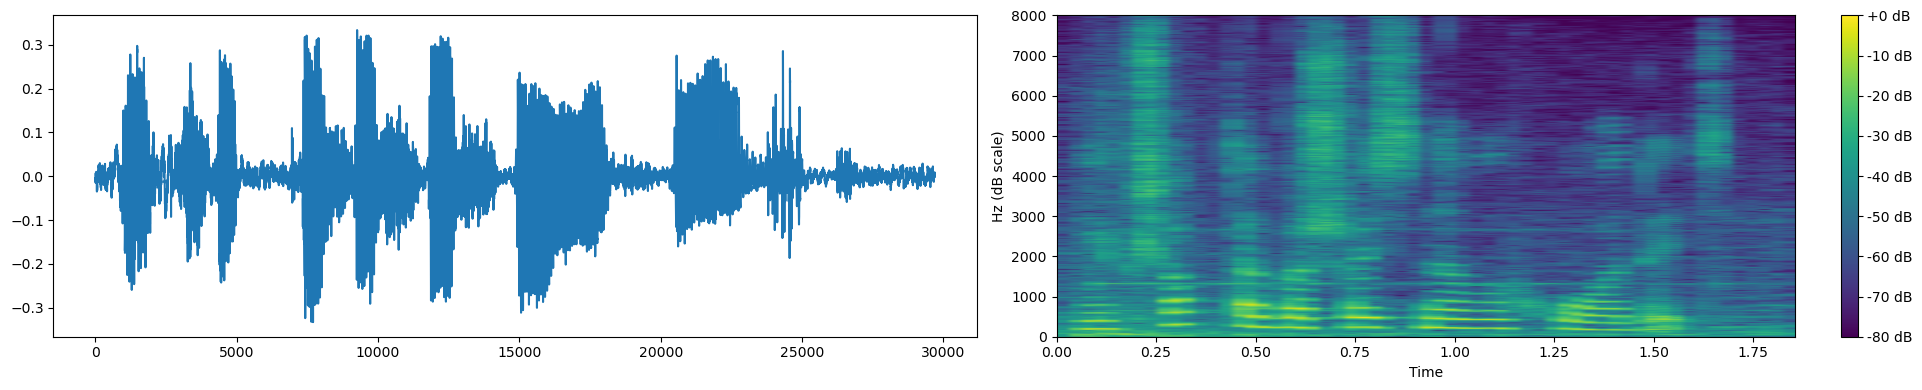

In [3]:

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa
import IPython.display as ipd
from matplotlib.ticker import MaxNLocator

SR = 16000
CLIPS_DIR = Path(DATA_DIR) / "clips"

df = pd.read_csv(Path(DATA_DIR) / "dataset.csv")
df["sex"] = df["filename"].apply(lambda x: 'female' if int(x.split(".")[0].split("_")[-1]) else 'male')
df["nwords"] = df["text"].apply(lambda x: len(x.split(' ')))

test = df[df["split"] == "train"]

SAMPLE = test.iloc[0]
SAMPLE_PATH = CLIPS_DIR / SAMPLE['filename']

y, sr = librosa.load(SAMPLE_PATH, sr=SR)

stfy_y = np.abs(librosa.stft(y))
stfy_y = librosa.amplitude_to_db(stfy_y, ref=np.max)

print(f"Audio shape: {y.shape}, Sample rate: {sr}")
print(SAMPLE)
print(f"Audio duration: {len(y) / sr:.2f} seconds")

fig, ax = plt.subplots(ncols=2, figsize=(20, 4))
ax[0].plot(y)

img = ax[1].imshow(stfy_y, aspect='auto', origin='lower', extent=[0, len(y)/sr, 0, sr/2])
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Hz (dB scale)')
fig.colorbar(img, ax=ax[1], format='%+2.0f dB')

fig.tight_layout()
fig.show()

ipd.Audio(SAMPLE_PATH)


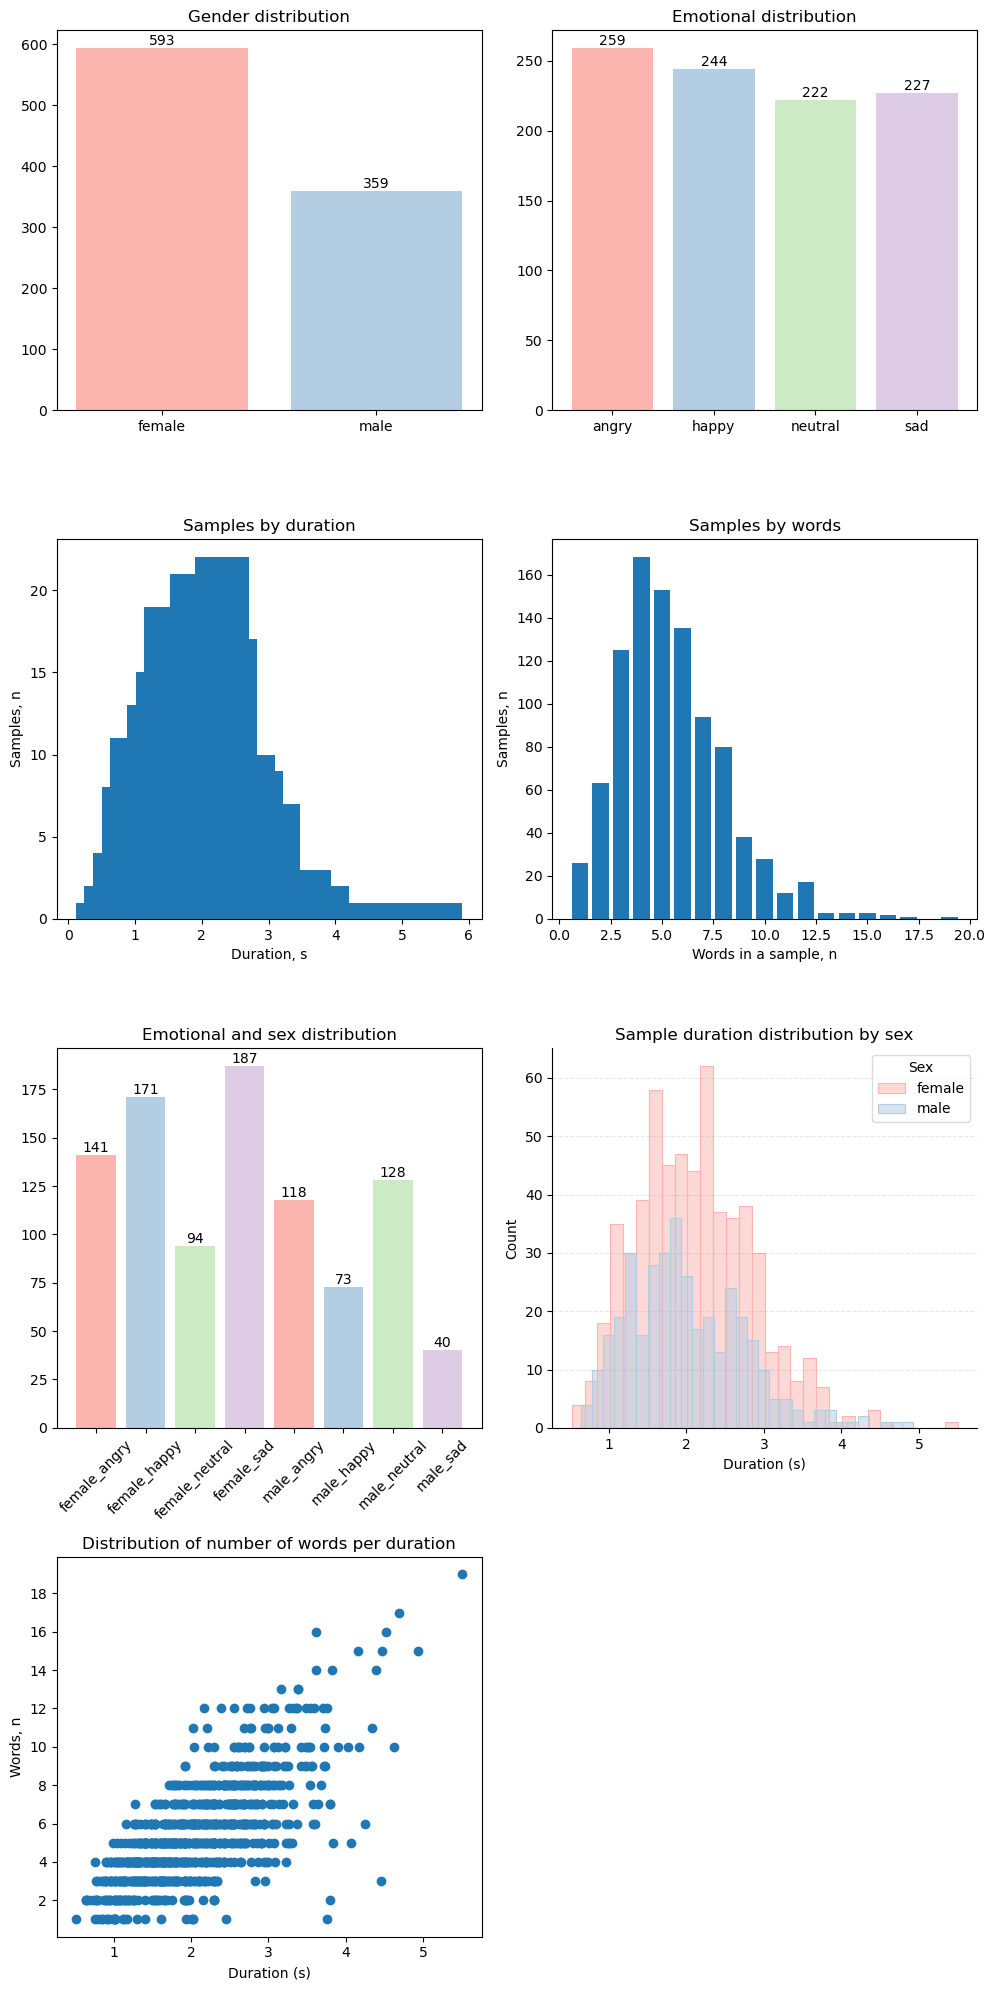

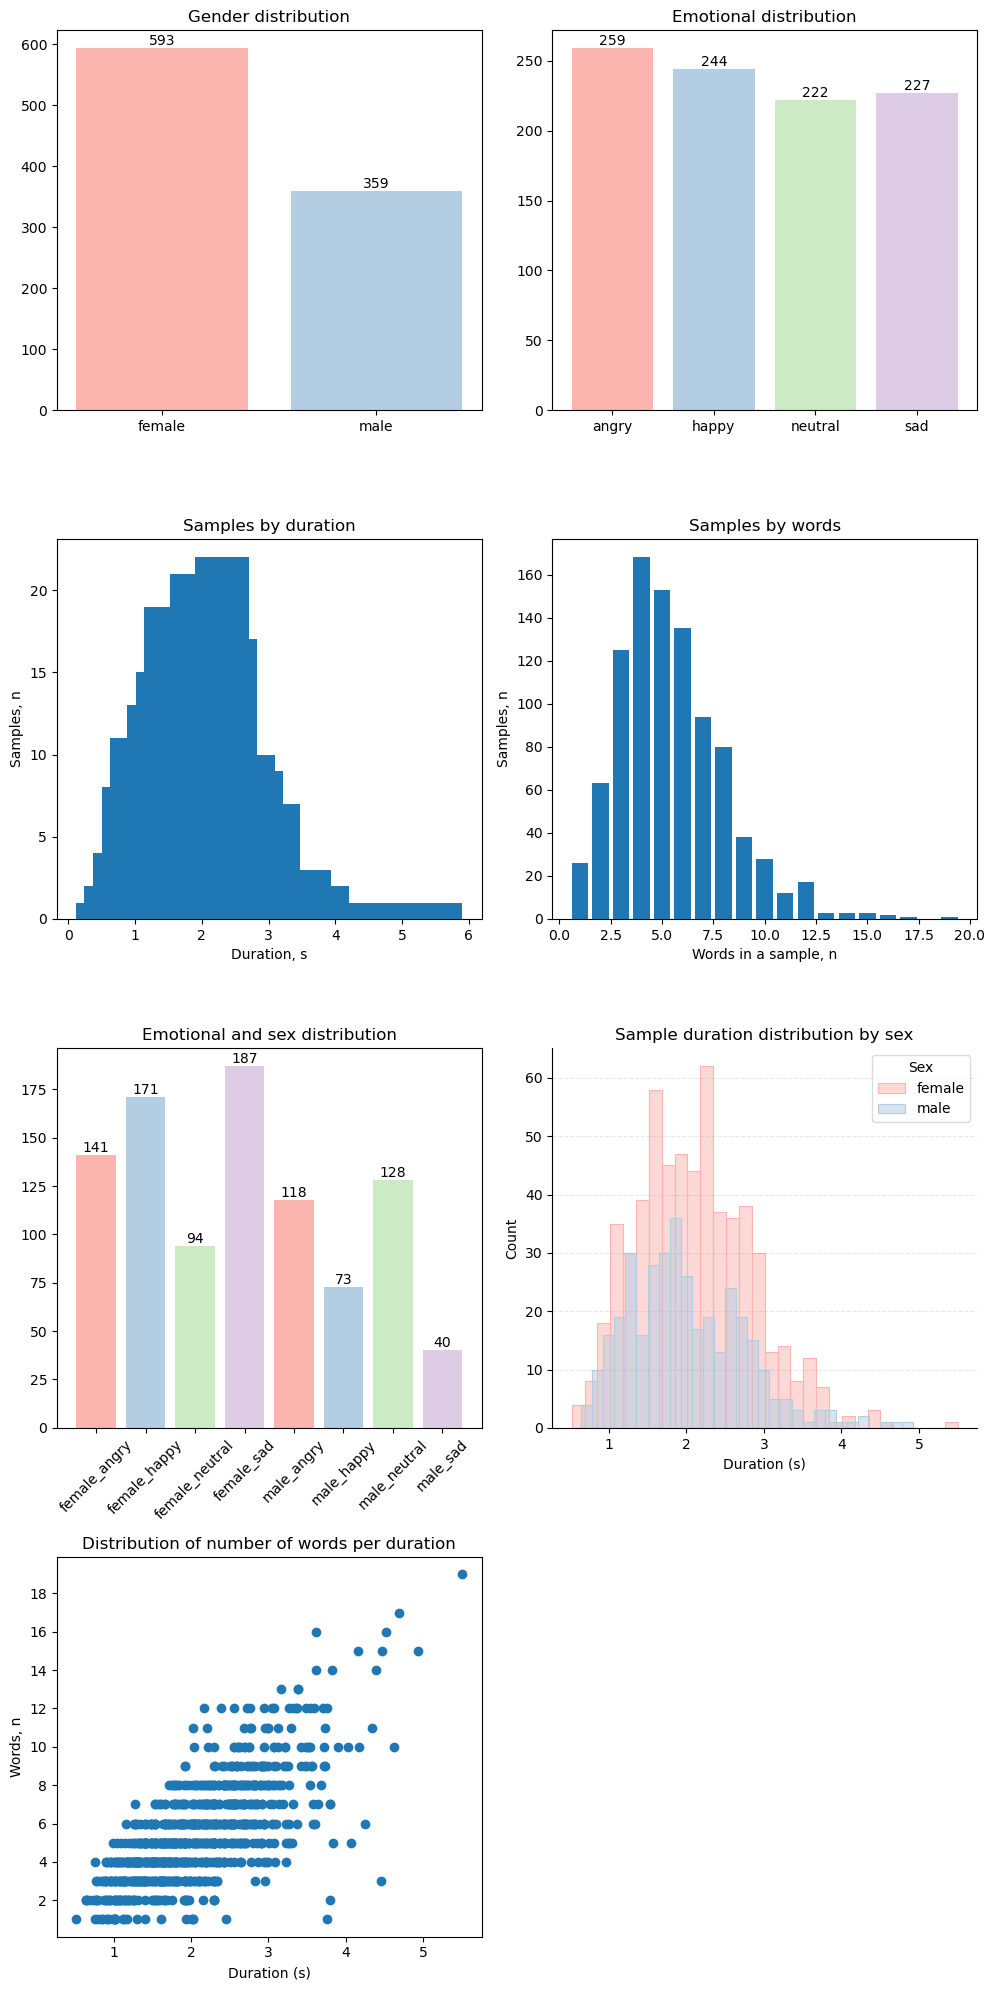

In [4]:
from plot_dataset import plot_dataset 

plot_dataset(df)

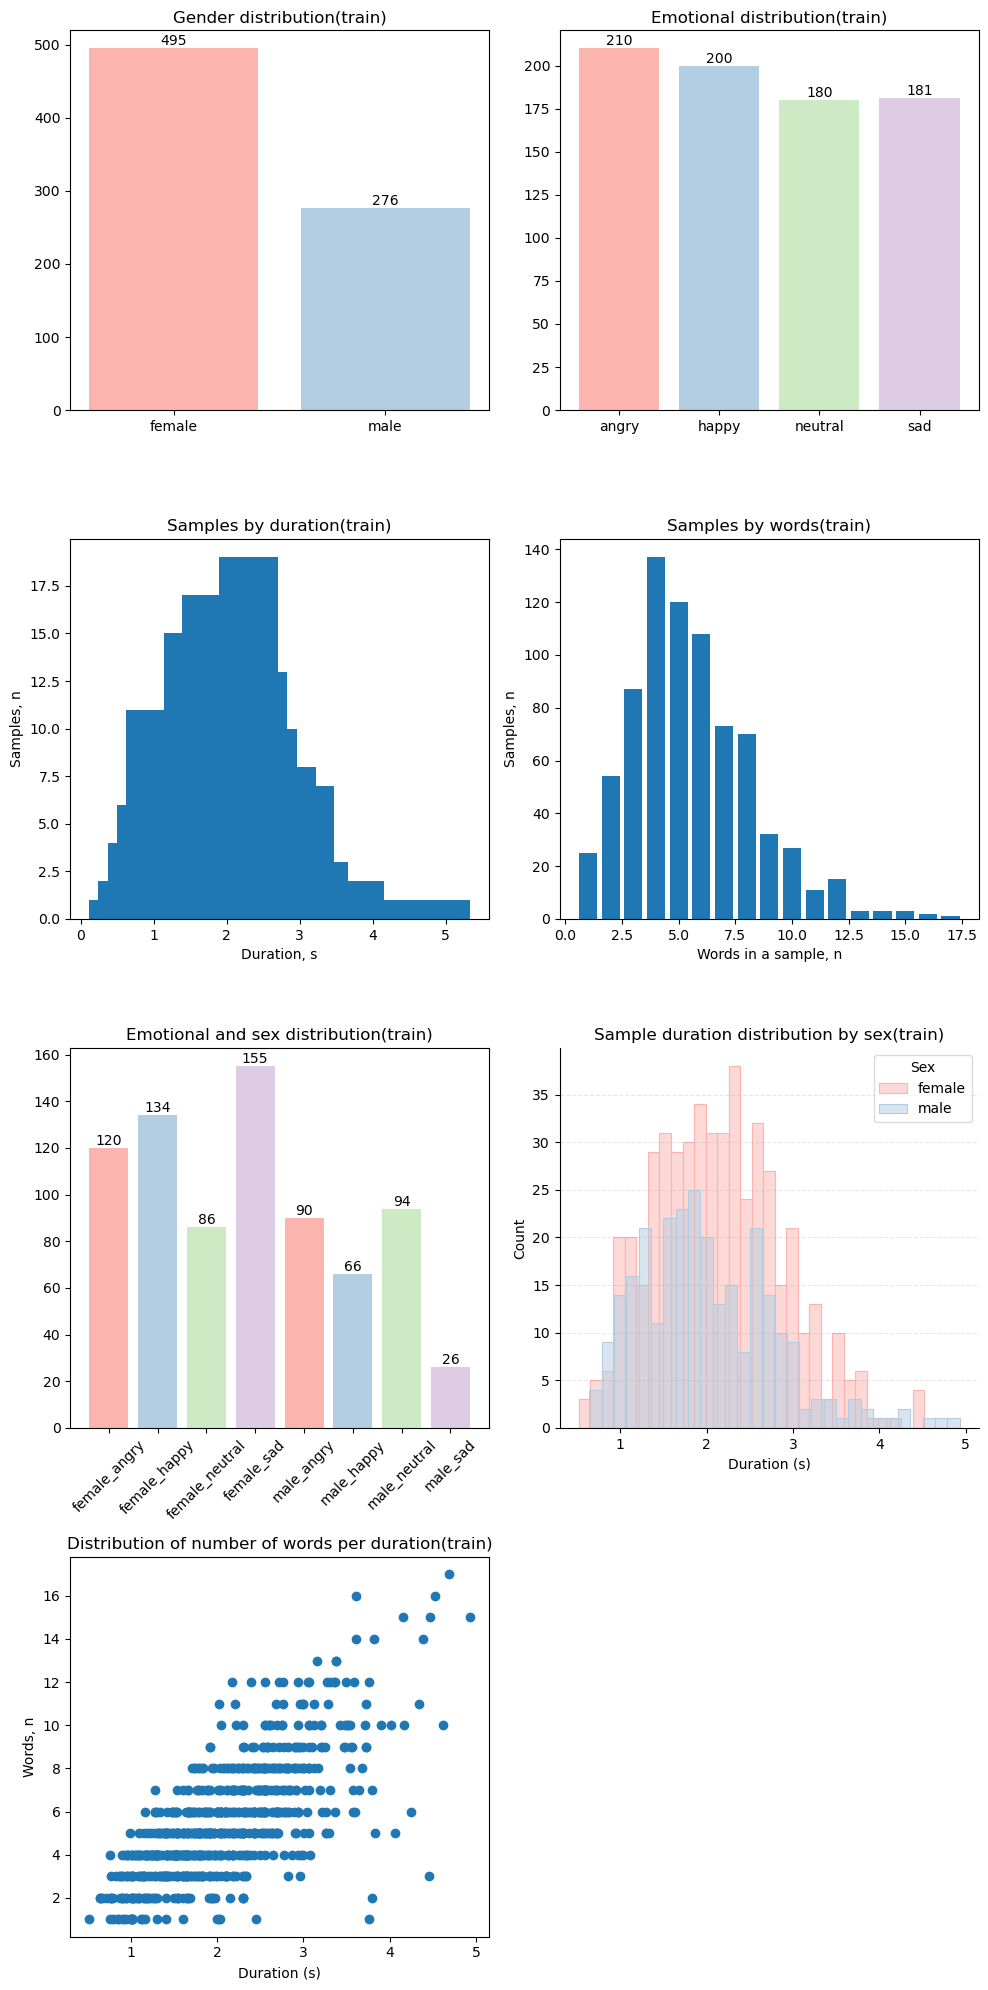

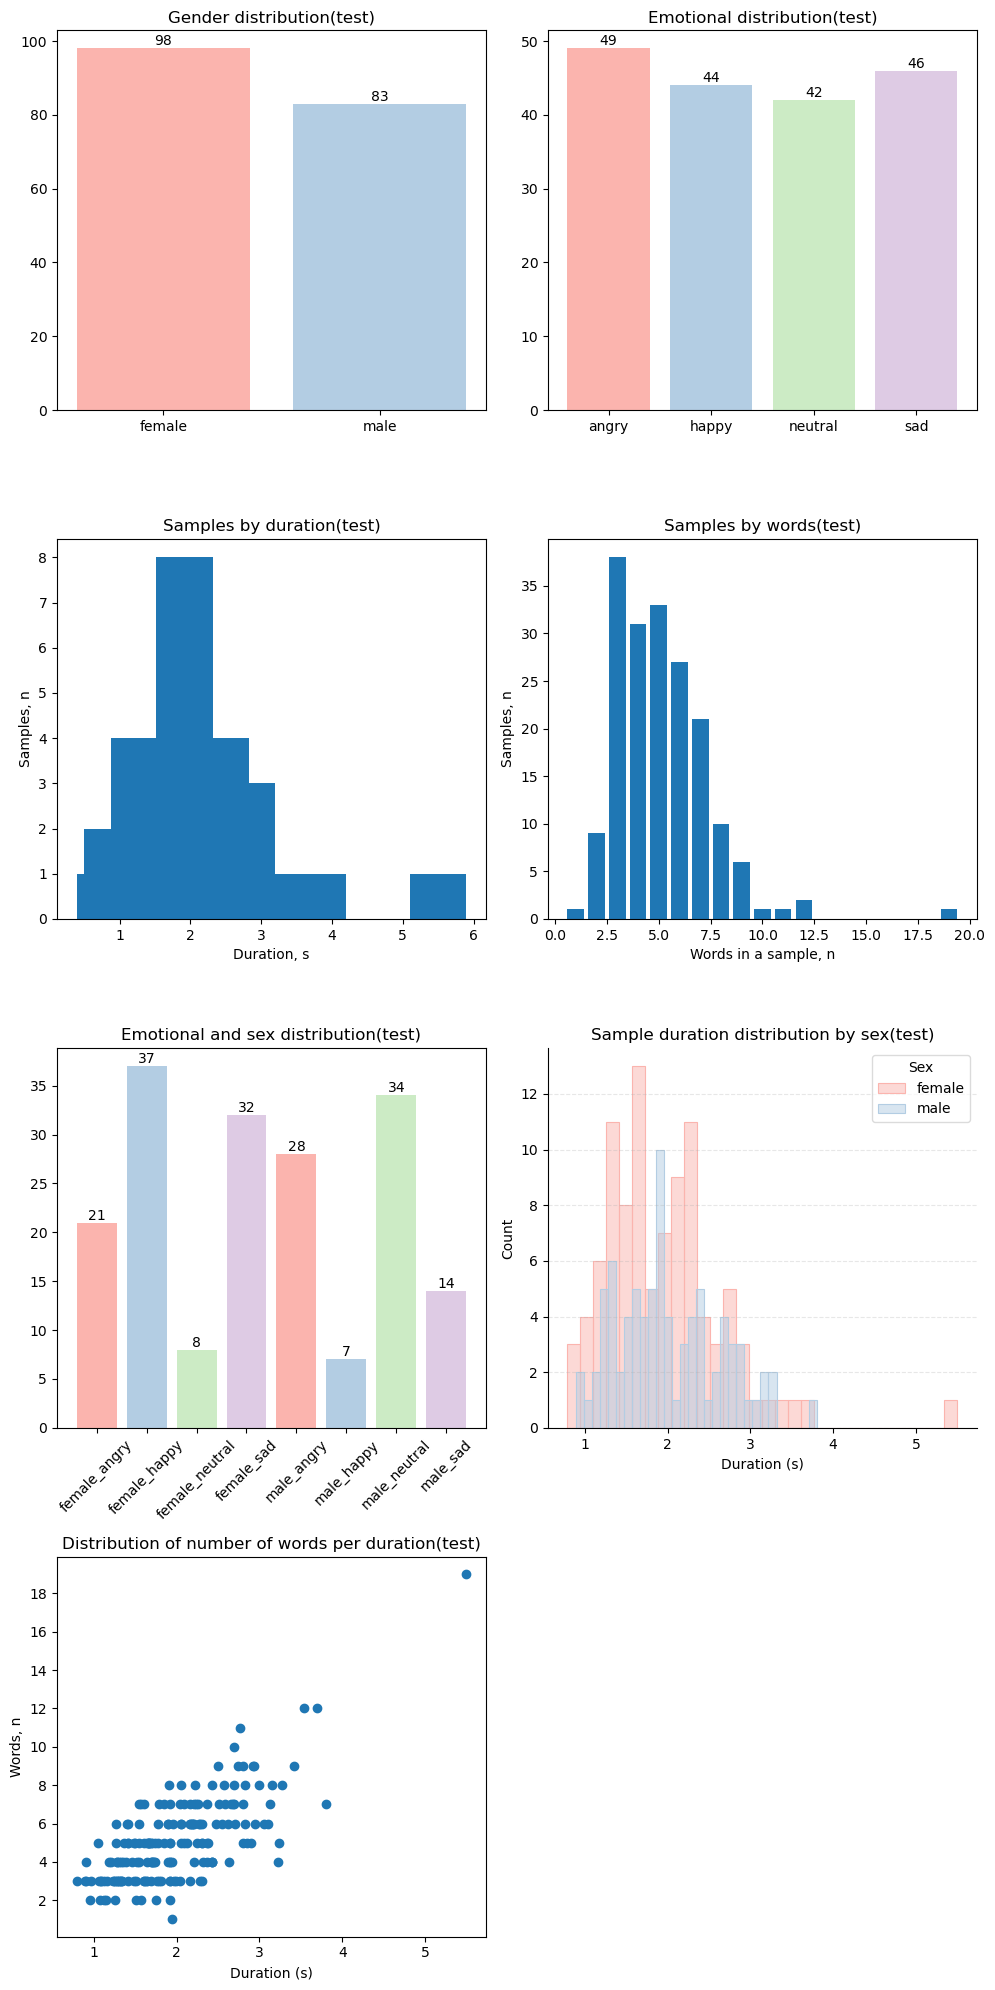

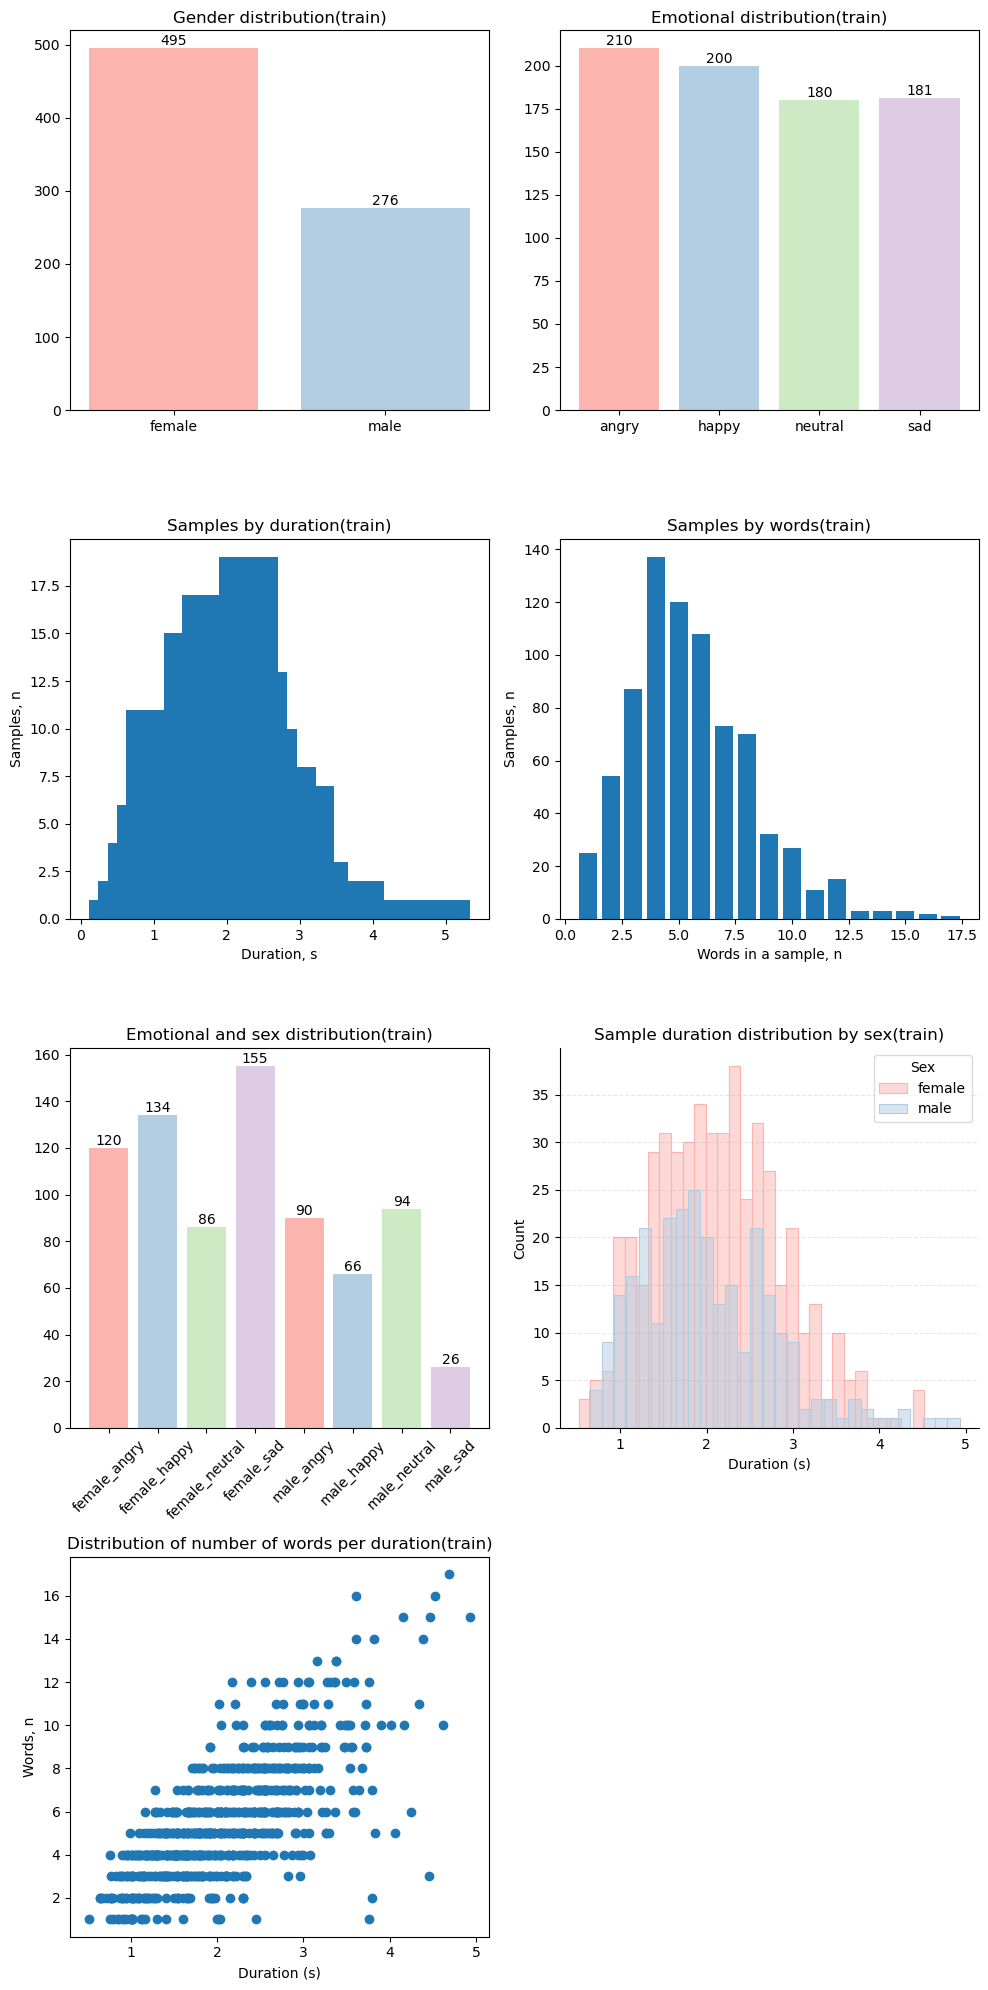

In [5]:
from plot_dataset import plot_dataset 

plot_dataset(df[df['split'] == 'test'], suffix='(test)')
plot_dataset(df[df['split'] == 'train'], suffix='(train)')

- Analyze the proposed target metric (UAR): discuss its strengths, weaknesses, and potential edge cases. TIP: Check metrics from the next subsection: “Compare with the Dataset Author's work”

the formula  

**UAR = 1/N * Sum(TPi / TPi + FNi)**  

where N - number of classes  
TPi - true positive of class i, correctly predicted as i  
FNi - false negatives of calss i, actually class i, but predicted as something else  
TPi + FNi - total true samples of class i  


**strength:**  
handles class imbalance(as we somewhat have in the dataset), each class contribute equally 
reflects real goal of class prediction, that's what we care about  
kind of a standart across datasets  

**weaknessses:**   
ignores precision  
doesnt account for false positives  
doesnt account for sample size, results may be equal, but it could be just by a random chance  
all classes are equal, that is not always the case  

**edge cases:** 
zero samples - division by 0  
small amount of samples for the class might drive scoring up while having a lot of false positives(could be the case for male saddness in the dataset)  
one poorly predicted class will drag others with itself  

- Suggest complementary metrics to capture other aspects of performance.

it would be usefull to capture false positives, also to check individual recalls of the classes, check results agains sample sizes of expected classes

- Propose an alternative target metric, with justification.

macro F1 - unweighted mean of per-class F1 scores, where F1 score is harmonic mean of precision and recall  
**macroF1 = 1/N * Sum(2 * Pi * Ri / Pi + Ri)**  


where:  
Pi = TPi / TPi + FPi - precision, of those predicted i, how many were right  
Ri = TPi / TPi + FNi - recall, of actual i, how many was caught  


harmonic mean in this case is better because its dominated by smaller value and it pulls the overall score down even if one value is poor(thats what we want)  
geometric mean also drops toward the smaller value, but if one of the terms is 0 - the whole value is 0  


todo: think and discuss weighted approaches  

### Validation:
- Use native train/test split. Design a separate validation split from the train set

overlap: False


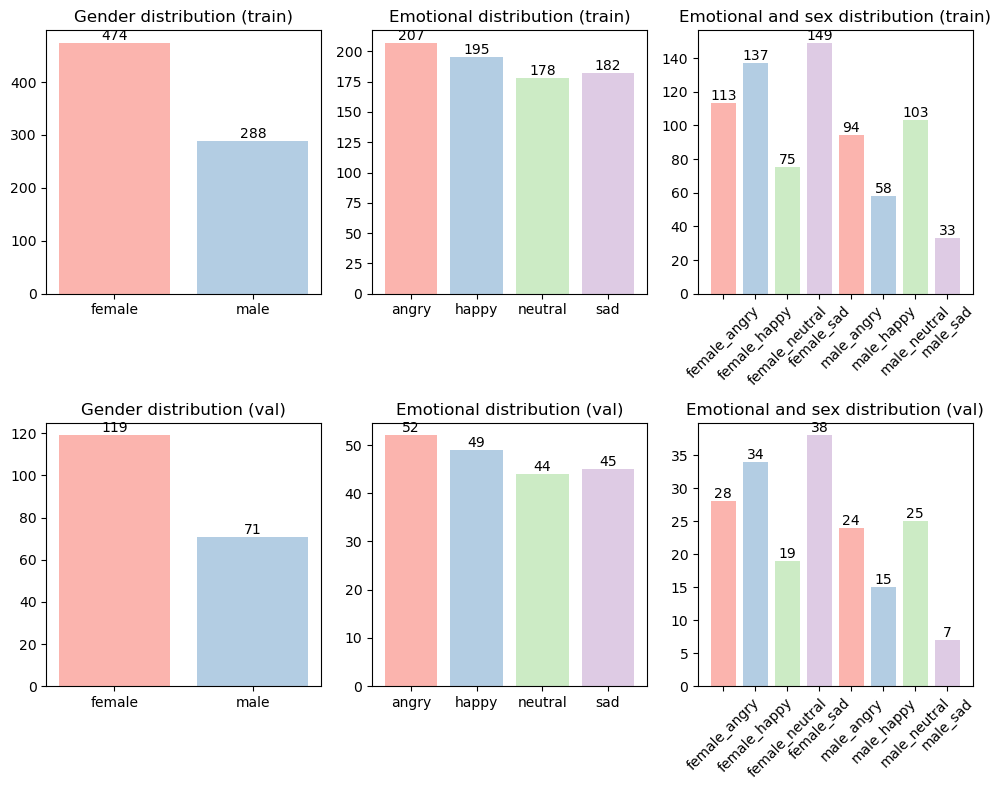

In [10]:
from sklearn.model_selection import StratifiedGroupKFold
from plot_dataset import plot_gender, plot_emotion, plot_sex_emotion


df["strat_key"] = df["emotion"].astype(str) + "_" + df["sex"].astype(str)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
train_idx, val_idx = next(sgkf.split(df, df["strat_key"], groups=df["speaker_id"]))

train_df = df.iloc[train_idx]
val_df   = df.iloc[val_idx]

fig, ax = plt.subplots(2, 3, figsize=(10, 8))
plot_gender(train_df,      ax[0, 0], suffix=' (train)')
plot_emotion(train_df,     ax[0, 1], suffix=' (train)')
plot_sex_emotion(train_df, ax[0, 2], suffix=' (train)')
plot_gender(val_df,        ax[1, 0], suffix=' (val)')
plot_emotion(val_df,       ax[1, 1], suffix=' (val)')
plot_sex_emotion(val_df,   ax[1, 2], suffix=' (val)')
fig.tight_layout()

print("overlap:", len(set(train_df.speaker_id) & set(val_df.speaker_id)) != 0)


- Explain your motivation for the chosen strategy and the importance of balancing gender and emotion classes within the splits.  

the core idea of the split is to keep speakers separated to prevent the data leakage and then to keep the distribution as similar as possible
its important to keep the data distribution similar to prevent biases - e.g if the model is trained on mostly positive emotions, it will poorly predict/distinguish between neutral-sad ones  
even though the data distribution of emotions is similar, at the gender level we can see that neutral emotions are coming from male samples and sad ones from female samples. even if we were to account for a similar emotion distribution, it would bias toward female sadness and male neutral emotions, and we would have a similar problem to the one described above  

the approach is to first group the data by speaker_id and greedily stratify gender/emotion pairs. luckily for us, there is already a function for that and we dont have to implement it ourselves. it's also already shaped for the k-fold validation approach, in case we proceed with it


- Discuss the challenges of achieving balanced class distributions in naturalistic emotion datasets.  
distribution of emotions in the real world
distinguishing between similar emotions and that emotion is not a boolean/signle label value

### Spectral Features (MelSpec, MFCC):
- Extract handcrafted acoustic features (e.g., MFCCs, Pitch/F0, RMS energy, Zero-Crossing Rate).
- Explore classical machine learning classifiers or simple neural networks to establish a baseline for the 4-class emotion classification problem.
- Collect all relevant results:
- metrics (UAR, Accuracy, Macro F1)
- hard samples analysis (e.g., structural variations between neutral and sad, or angry and happy).
- Conclude whether acoustic features alone are adequate.
- Prepare an ablation study on the tested models

### Self-Supervised Approach (Data2Vec, Wave2Vec, …):
- Explore pre-trained self-supervised speech approaches, contrasting language-transfer models (e.g., wav2vec2-xls-r-300m-uk) with task-transfer models (e.g., emotion2vec+).
- Collect all relevant results:
- metrics (focusing on Unweighted Average Recall)
- hard samples analysis.
- Conclude whether the model is adequate.
- Prepare an ablation study on the tested models, exploring freezing depths (e.g., number of frozen transformer blocks), loss functions (Focal Loss vs. Cross-Entropy), and data augmentation techniques.

### Compare with the Dataset Author's work
- Explore the approach proposed by Olha Havryluk
- Explain how your approach differs from baseline and why is it better

### Final Report
- Prepare a comprehensive report including:
- data insights,
- feature engineering,
- tried algorithms and models,
- chosen hyperparameters,
- metrics,
- insights and conclusions.
- Reports may be prepared in LaTeX or Markdown (README.md).